# Lab №4 Robot Manipulator Control with PD Controller

### 0. Import the necessary libraries  

In [555]:
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

### 1. Import the  model

In [556]:
robot = rtb.models.DH.Stanford()
print(robot)

DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

### 2. Fill in the parameters of the robot model (in the example, filled in for the Puma560 robot)

0. Using dyn() you can view the dynamic parameters of each link

In [557]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =       9.3 
r     =         0    0.018    -0.11 
        |     0.28        0        0 | 
I     = |        0     0.26        0 | 
        |        0        0    0.071 | 
Jm    =      0.95 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3


1. Let's define the mass of the links

In [558]:
# Masses (kg) - Approximated for Stanford arm
robot.links[0].m = 9.29    # Base
robot.links[1].m = 5.01    # Shoulder
robot.links[2].m = 4.25    # Elbow (prismatic joint)
robot.links[3].m = 1.08    # Wrist 1
robot.links[4].m = 0.63    # Wrist 2
robot.links[5].m = 0.51    # End-effector

2. Let's define the center of mass of each link

In [559]:
# Center of Mass (m) - Relative to link frames
robot.links[0].r = [0, 0, 0.1]          # Base CoM offset
robot.links[1].r = [0, -0.02, 0.12]     # Shoulder CoM
robot.links[2].r = [0, 0, 0.25]         # Elbow CoM (prismatic)
robot.links[3].r = [0, 0.01, 0.02]      # Wrist 1 CoM
robot.links[4].r = [0, 0, 0.01]         # Wrist 2 CoM
robot.links[5].r = [0, 0, 0.03]         # End-effector CoM

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [560]:
# Inertia Tensors (kg·m²) - Diagonal approximations [Ixx, Iyy, Izz, Ixy, Iyz, Ixz]
robot.links[0].I = [0.1, 0.1, 0.05, 0, 0, 0]    # Base
robot.links[1].I = [0.05, 0.2, 0.15, 0, 0, 0]   # Shoulder
robot.links[2].I = [0.01, 0.01, 0.02, 0, 0, 0]  # Elbow
robot.links[3].I = [0.005, 0.003, 0.004, 0, 0, 0]  # Wrist 1
robot.links[4].I = [0.002, 0.002, 0.001, 0, 0, 0]  # Wrist 2
robot.links[5].I = [0.001, 0.001, 0.001, 0, 0, 0]  # End-effector

4. Let's set the moment of inertia of the drive

In [561]:
# Motor Inertia (kg·m²) - Typical servo values
robot.links[0].Jm = 0.0002    # Base motor
robot.links[1].Jm = 0.0002    # Shoulder motor
robot.links[2].Jm = 0.0001    # Elbow motor (prismatic)
robot.links[3].Jm = 0.00005   # Wrist 1 motor
robot.links[4].Jm = 0.00005   # Wrist 2 motor
robot.links[5].Jm = 0.00003   # End-effector motor

5. Let's define the coefficient of viscous friction of the drive

In [562]:
# Viscous Friction (N·m·s/rad)
robot.links[0].B = 0.01    # Base
robot.links[1].B = 0.008   # Shoulder
robot.links[2].B = 0.005   # Elbow
robot.links[3].B = 0.001   # Wrist 1
robot.links[4].B = 0.001   # Wrist 2
robot.links[5].B = 0.0005  # End-effector

6. Let's define the coefficient of Coulomb friction of the drive

In [563]:
# Coulomb Friction (N·m) - [T⁺, T⁻] for asymmetric friction
robot.links[0].Tc = [0.05, -0.06]   # Base
robot.links[1].Tc = [0.04, -0.05]   # Shoulder
robot.links[2].Tc = [0.02, -0.03]   # Elbow
robot.links[3].Tc = [0.01, -0.015]  # Wrist 1
robot.links[4].Tc = [0.01, -0.015]  # Wrist 2
robot.links[5].Tc = [0.005, -0.01]  # End-effector

7. Let's set the gear ratio for each link

In [564]:
# Gear Ratios (motor:joint)
robot.links[0].G = 120    # Base
robot.links[1].G = 100    # Shoulder
robot.links[2].G = 80     # Elbow
robot.links[3].G = 50     # Wrist 1
robot.links[4].G = 50     # Wrist 2
robot.links[5].G = 30     # End-effector

8. Let's set restrictions on the generalized coordinates for each link

In [565]:
# Joint Limits (radians)
robot.links[0].qlim = [-pi, pi]      # Base rotation
robot.links[1].qlim = [-pi, pi]      # Shoulder
robot.links[2].qlim = [0, 0.5]       # Elbow (prismatic)
robot.links[3].qlim = [-pi, pi]      # Wrist 1
robot.links[4].qlim = [-pi, pi]      # Wrist 2
robot.links[5].qlim = [-pi, pi]      # End-effector

### 3. Set the initial and final positions of the robot and plot them

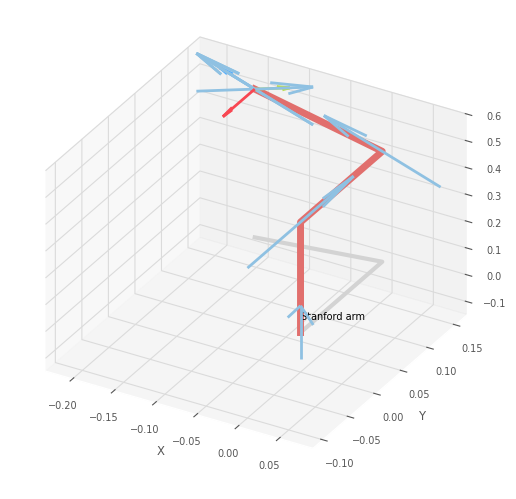

<Figure size 640x480 with 0 Axes>

In [566]:
q_start = [0, -pi/4, 0.2, 0, 0, 0]
robot.plot(q_start)
plt.show()

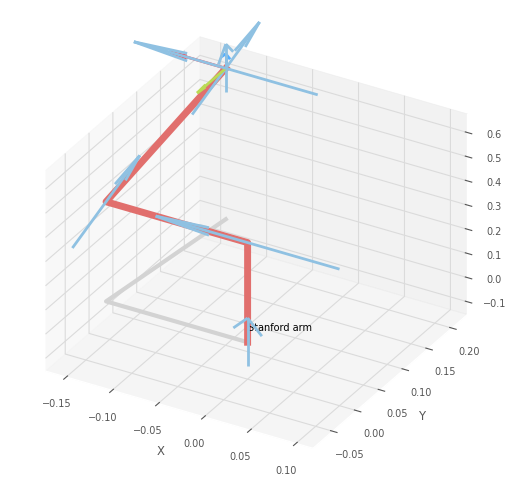

<Figure size 640x480 with 0 Axes>

In [567]:
q_end = [pi/2, pi/4, 0.3, pi/2, -pi/4, pi/2]
robot.plot(q_end)
plt.show()

Set the time array  

In [569]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)

Generate the full manipulator trajectory  

In [570]:
traj = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

### 4. Synthesize the control loop  

Set the PD controller coefficients (two 6x6 matrices)  

In [571]:
# After tuning, these values were found to work well
Kp = np.diag([3000, 2500, 2000, 150, 200, 50])  # Proportional gains
Kd = np.diag([1000, 750, 500, 30, 20, 10])       # Derivative gains

Initialize arrays for data storage  

In [572]:
torques = []
errors = []
actual_positions = []
actual_velocities = []

Synthesize the PD controller  

In [573]:
def PD_regulator(robot, t, q_act, qd_act):
    # Save actual positions and velocities
    actual_positions.append(q_act)
    actual_velocities.append(qd_act)
    
    # Determine the array element (index) corresponding to the current time     
    mask = np.round(np.abs(time-t),3) <= t_shag
    list_idx = np.array(range(len(mask)))
    idx = list_idx[mask][0]
    
    # Extract position, velocity, and acceleration at the current time      
    q_des = traj.q[idx]
    qd_des = traj.qd[idx]
    qdd_des = traj.qdd[idx]

    # Compute the position and velocity errors
    q_err = q_des - q_act
    qd_err = qd_des - qd_act

    # Obtain the components of the dynamic equation  
    M = robot.inertia(q_act)
    C = robot.coriolis(q_act, qd_act)
    G = robot.gravload(q_act)

    # Compute the control input using inverse dynamics PD control
    tau = Kp @ q_err + Kd @ qd_err + M @ qdd_des + C @ qd_des + G

    # Save values for plotting
    torques.append(tau)
    errors.append(q_err)

    return tau

Solve the forward dynamics problem  

In [574]:
tg = robot.fdyn(t_stop, q_start, PD_regulator, dt=t_shag, progress=True, solver="RK45", solver_args={"atol":1e-3,"rtol":1e-2}) 

### 5. Plot the graphs  

Plot the position graph  

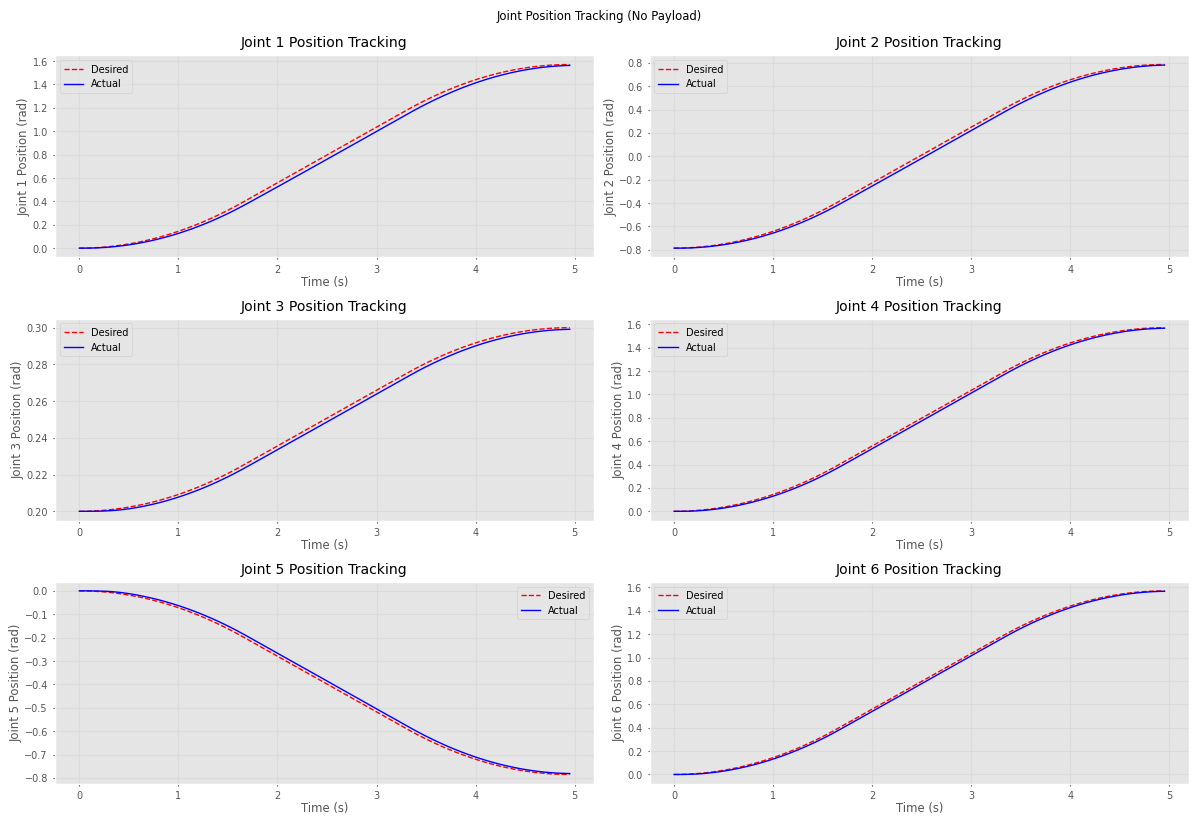

In [592]:
# 6. Plot the graphs - Final Corrected Version

# Get simulation results
sim_time = tg.t
sim_q = tg.q

# Ensure matching dimensions
min_length = min(len(sim_time), len(traj.q), len(sim_q))
sim_time = sim_time[:min_length]
sim_q = sim_q[:min_length]
traj_q = traj.q[:min_length]
traj_qd = traj.qd[:min_length]

# Position plots
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time, traj_q[:,i], 'r--', label='Desired', linewidth=1)
    plt.plot(sim_time, sim_q[:,i], 'b-', label='Actual', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Position (rad)')
    plt.title(f'Joint {i+1} Position Tracking')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Position Tracking (No Payload)', y=1.02)
plt.show()

Plot the velocity graph  

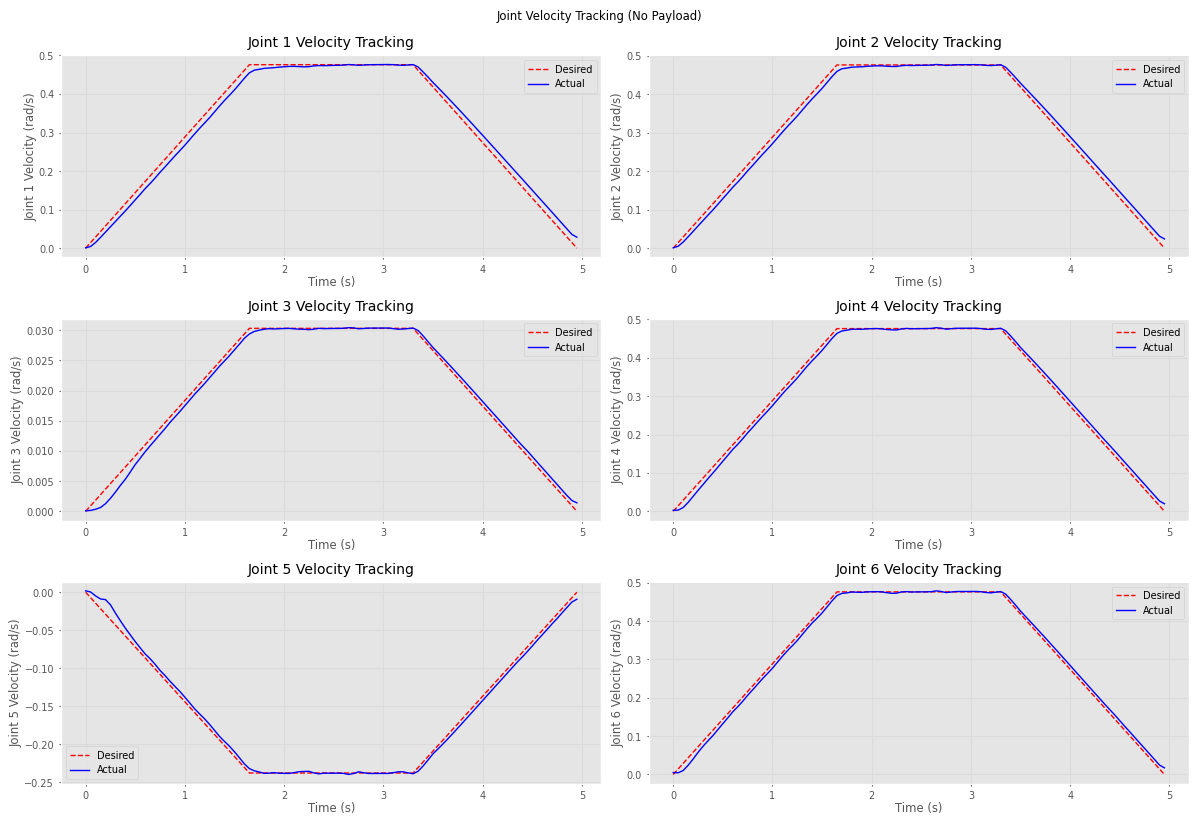

In [596]:
# Calculate velocities properly
sim_qd = np.zeros_like(sim_q)
dt = np.gradient(sim_time)
for i in range(6):  # Calculate derivative for each joint separately
    sim_qd[:,i] = np.gradient(sim_q[:,i]) / dt

# Velocity plots
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time, traj_qd[:,i], 'r--', label='Desired', linewidth=1)
    plt.plot(sim_time, sim_qd[:,i], 'b-', label='Actual', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Velocity (rad/s)')
    plt.title(f'Joint {i+1} Velocity Tracking')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Velocity Tracking (No Payload)', y=1.02)
plt.show()

Plot the torque graph  

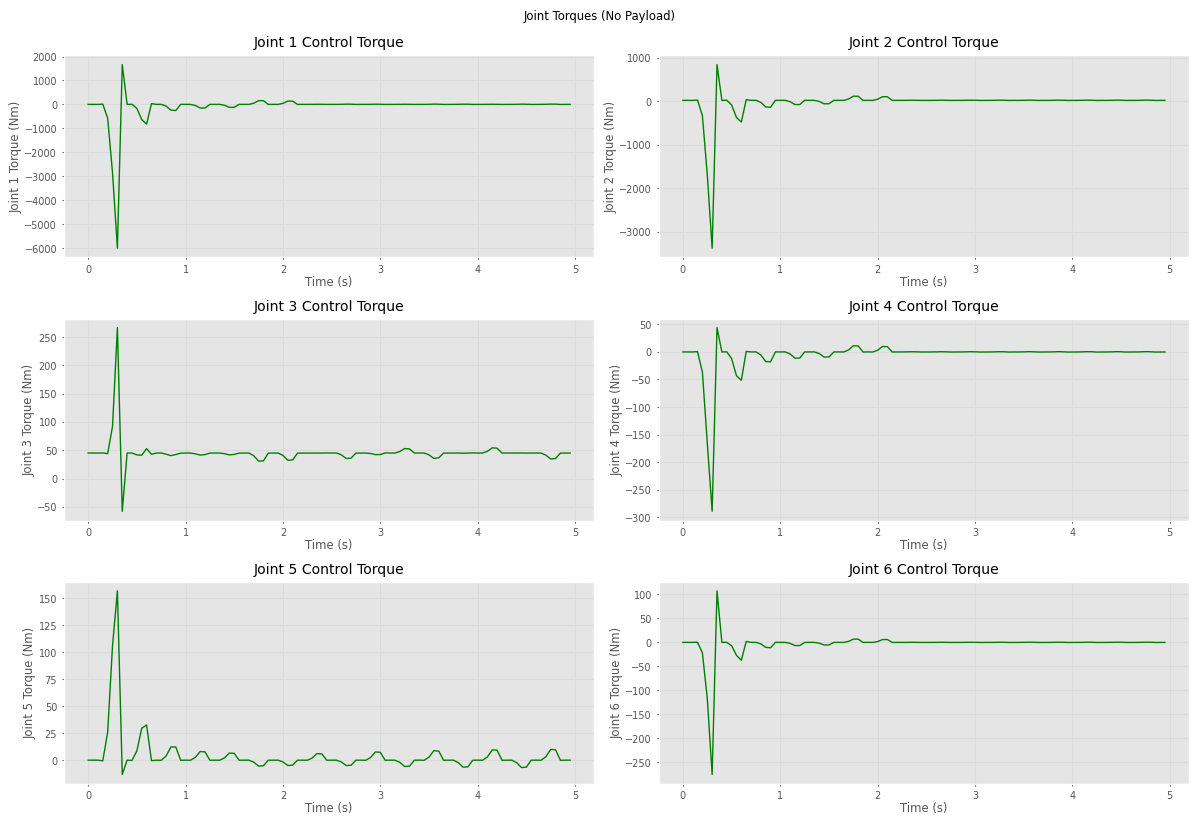

In [594]:
# Torque plots
if len(torques) > 0:
    stored_torques = np.array(torques)
    # Ensure we don't exceed time dimension
    plot_torques = stored_torques[:len(sim_time)]
    plt.figure(figsize=(12, 8))
    for i in range(6):
        plt.subplot(3, 2, i+1)
        plt.plot(sim_time[:len(plot_torques)], plot_torques[:,i], 'g-', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'Joint {i+1} Torque (Nm)')
        plt.title(f'Joint {i+1} Control Torque')
        plt.grid(True)
    plt.tight_layout()
    plt.suptitle('Joint Torques (No Payload)', y=1.02)
    plt.show()

Error plots

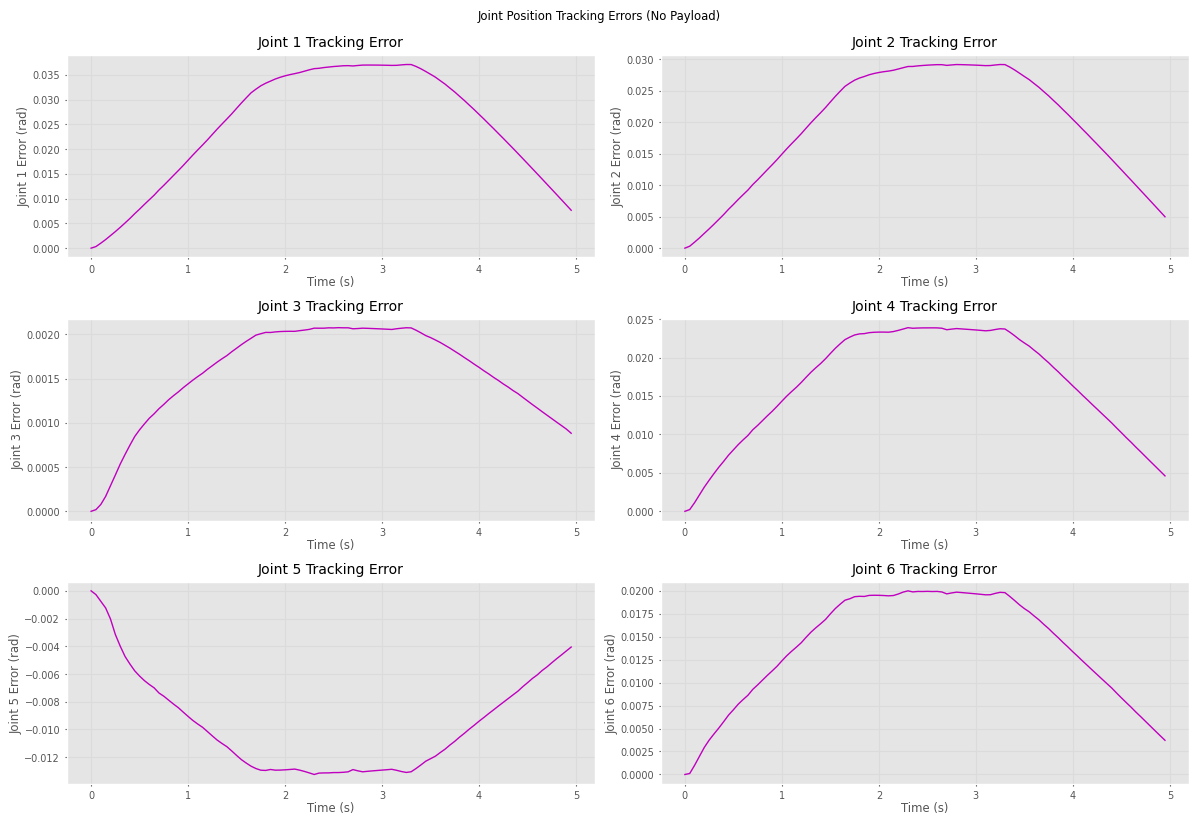

In [ ]:
# Calculate errors from actual vs desired positions
tracking_errors = traj_q[:len(sim_q)] - sim_q
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time, tracking_errors[:,i], 'm-', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Error (rad)')
    plt.title(f'Joint {i+1} Tracking Error')
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Position Tracking Errors (No Payload)', y=1.02)
plt.show()

### 6. Add a payload and solve the forward dynamics problem again  

Adding payload  

In [576]:
robot.payload(200) 

Initialize arrays for data storage  

In [577]:
# Reset storage arrays for payload simulation
payload_torques = []
payload_errors = []
payload_actual_positions = []
payload_actual_velocities = []

Synthesize the PD controller  

In [578]:
# Define a separate PD regulator for payload case to avoid mixing data
def PD_regulator_payload(robot, t, q_act, qd_act):
    # Save actual positions and velocities
    payload_actual_positions.append(q_act)
    payload_actual_velocities.append(qd_act)
    
    # Determine the array element (index) corresponding to the current time     
    mask = np.round(np.abs(time-t),3) <= t_shag
    list_idx = np.array(range(len(mask)))
    idx = list_idx[mask][0]
    
    # Extract position, velocity, and acceleration at the current time      
    q_des = traj.q[idx]
    qd_des = traj.qd[idx]
    qdd_des = traj.qdd[idx]

    # Compute the position and velocity errors
    q_err = q_des - q_act
    qd_err = qd_des - qd_act

    # Obtain the components of the dynamic equation  
    M = robot.inertia(q_act)
    C = robot.coriolis(q_act, qd_act)
    G = robot.gravload(q_act)

    # Compute the control input using inverse dynamics PD control
    tau = Kp @ q_err + Kd @ qd_err + M @ qdd_des + C @ qd_des + G

    # Save values for plotting
    payload_torques.append(tau)
    payload_errors.append(q_err)

    return tau

Solve the forward dynamics problem  

In [579]:
tg_load = robot.fdyn(t_stop, q_start, PD_regulator_payload, dt=t_shag, progress=True, solver="RK45", solver_args={"atol":1e-3,"rtol":1e-2})

Initialize arrays for data storage  

In [581]:
torques_with_payload = np.array(payload_torques)

Plot position graph with payload 

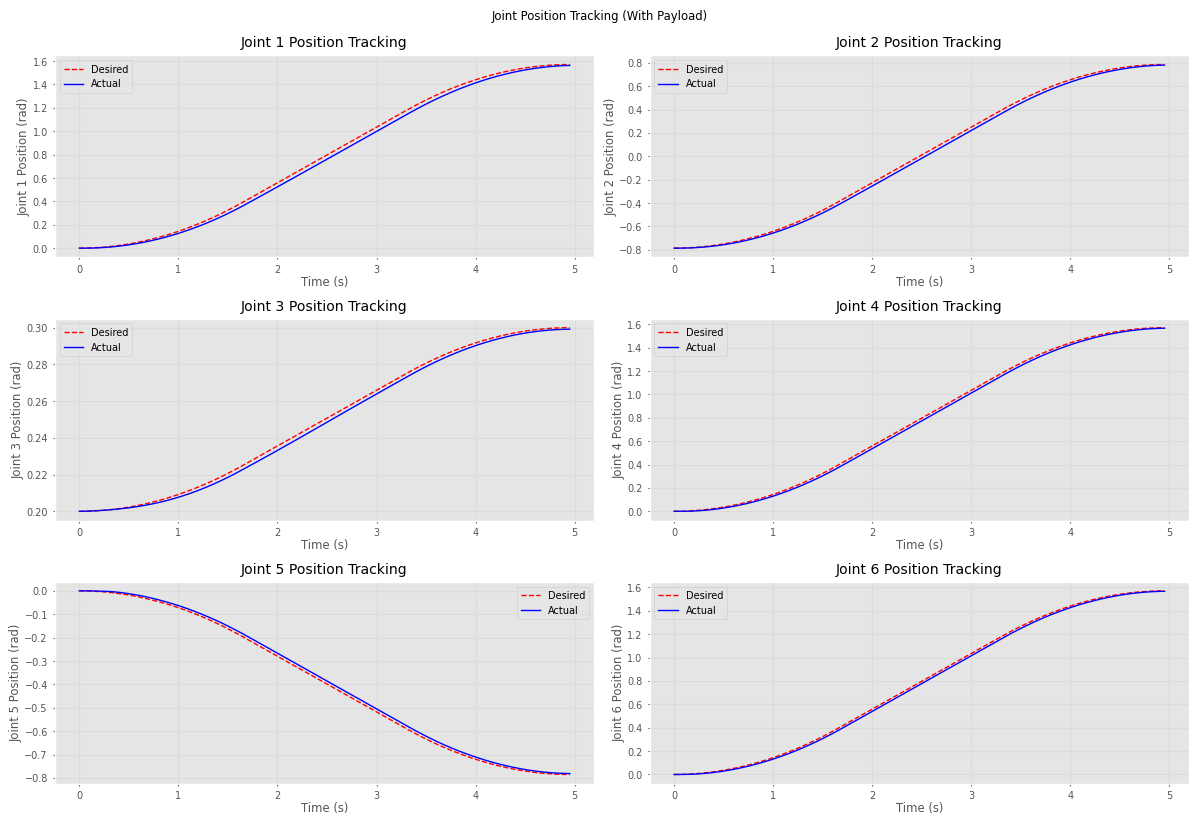

In [ ]:
# Get simulation results with payload
sim_time_load = tg_load.t
sim_q_load = tg_load.q

# Ensure matching dimensions for payload case
min_length_load = min(len(sim_time_load), len(traj.q), len(sim_q_load))
sim_time_load = sim_time_load[:min_length_load]
sim_q_load = sim_q_load[:min_length_load]
traj_q_load = traj.q[:min_length_load]
traj_qd_load = traj.qd[:min_length_load]

# Position plots with payload
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time_load, traj_q_load[:,i], 'r--', label='Desired', linewidth=1)
    plt.plot(sim_time_load, sim_q_load[:,i], 'b-', label='Actual', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Position (rad)')
    plt.title(f'Joint {i+1} Position Tracking')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Position Tracking (With Payload)', y=1.02)
plt.show()

Plot veocity graph with payload  

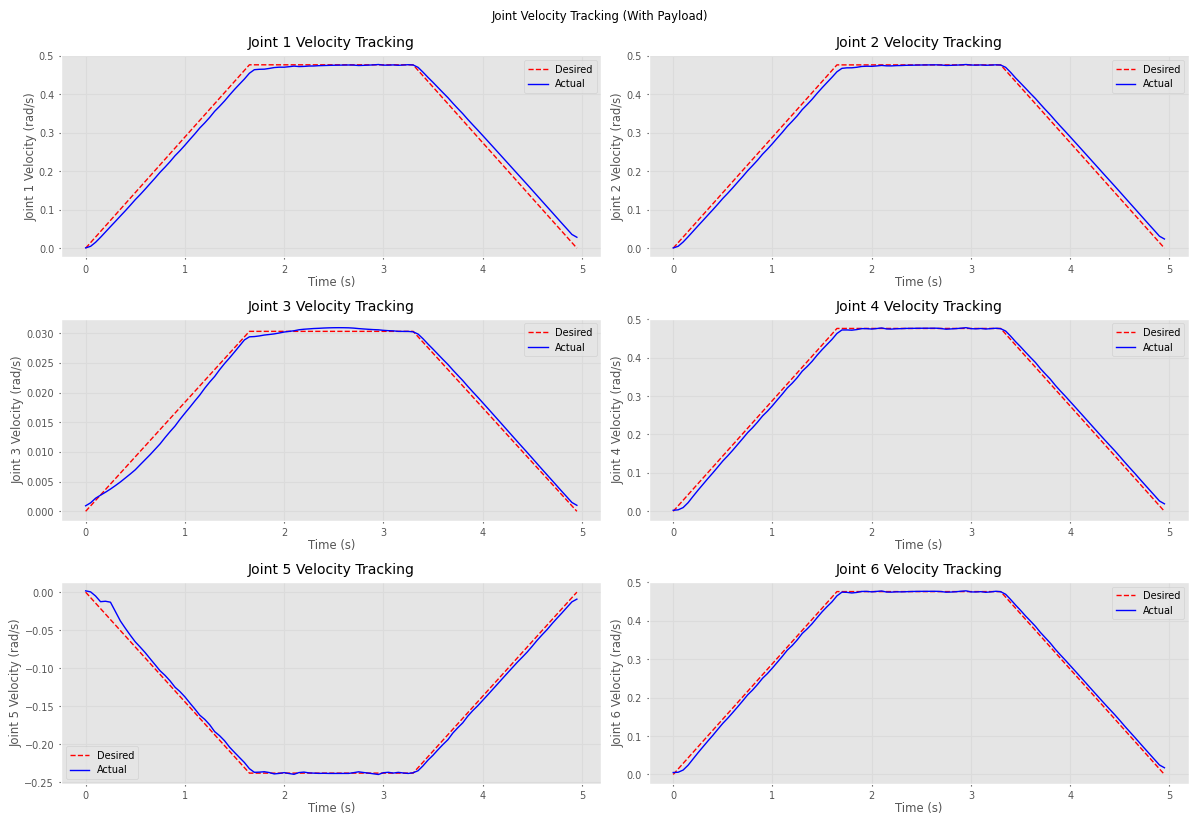

In [599]:
# Calculate velocities properly for payload case
sim_qd_load = np.zeros_like(sim_q_load)
dt_load = np.gradient(sim_time_load)
for i in range(6):
    sim_qd_load[:,i] = np.gradient(sim_q_load[:,i]) / dt_load

# Velocity plots with payload
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time_load, traj_qd_load[:,i], 'r--', label='Desired', linewidth=1)
    plt.plot(sim_time_load, sim_qd_load[:,i], 'b-', label='Actual', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Velocity (rad/s)')
    plt.title(f'Joint {i+1} Velocity Tracking')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Velocity Tracking (With Payload)', y=1.02)
plt.show()

Plot torque graph with payload 

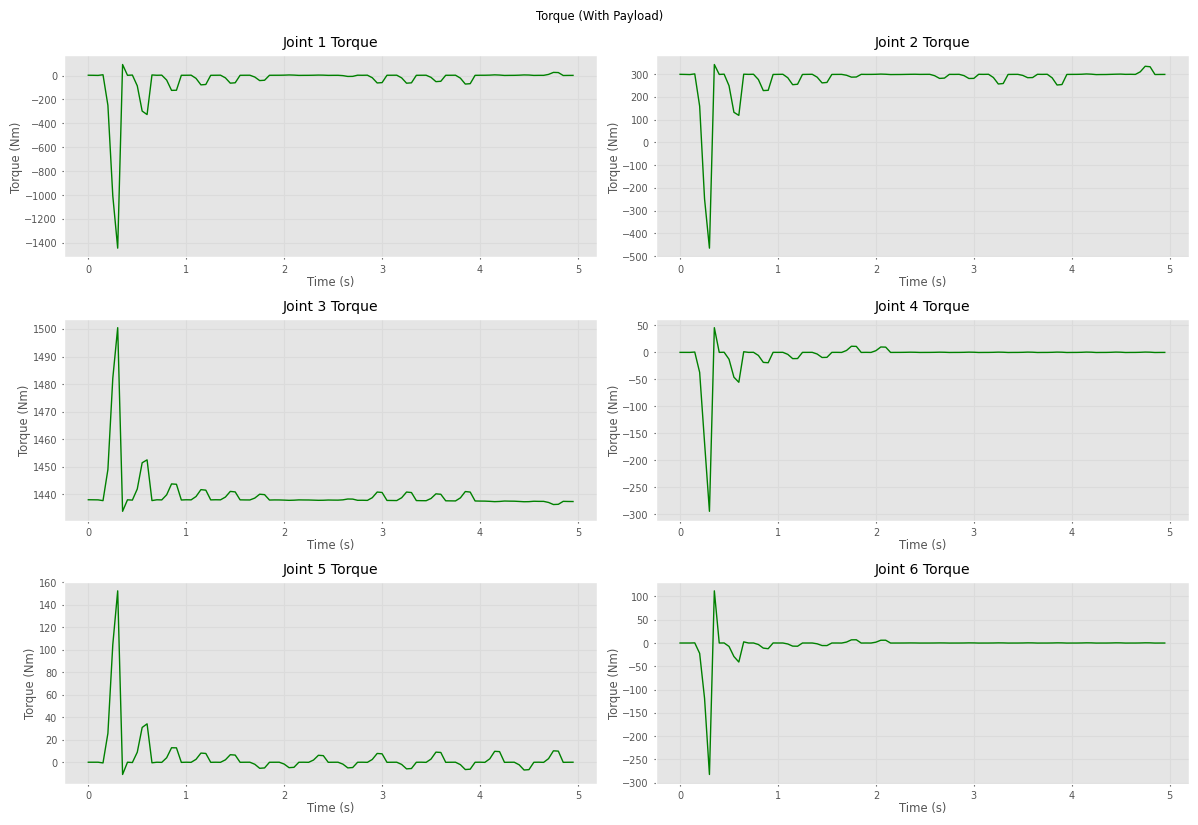

In [601]:
# Torque with payload
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(tg_load.t, torques_with_payload[:len(tg_load.t), i], 'g-', linewidth=1)
    plt.title(f'Joint {i+1} Torque')
    plt.xlabel('Time (s)')
    plt.ylabel('Torque (Nm)')
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Torque (With Payload)', y=1.02)
plt.show()

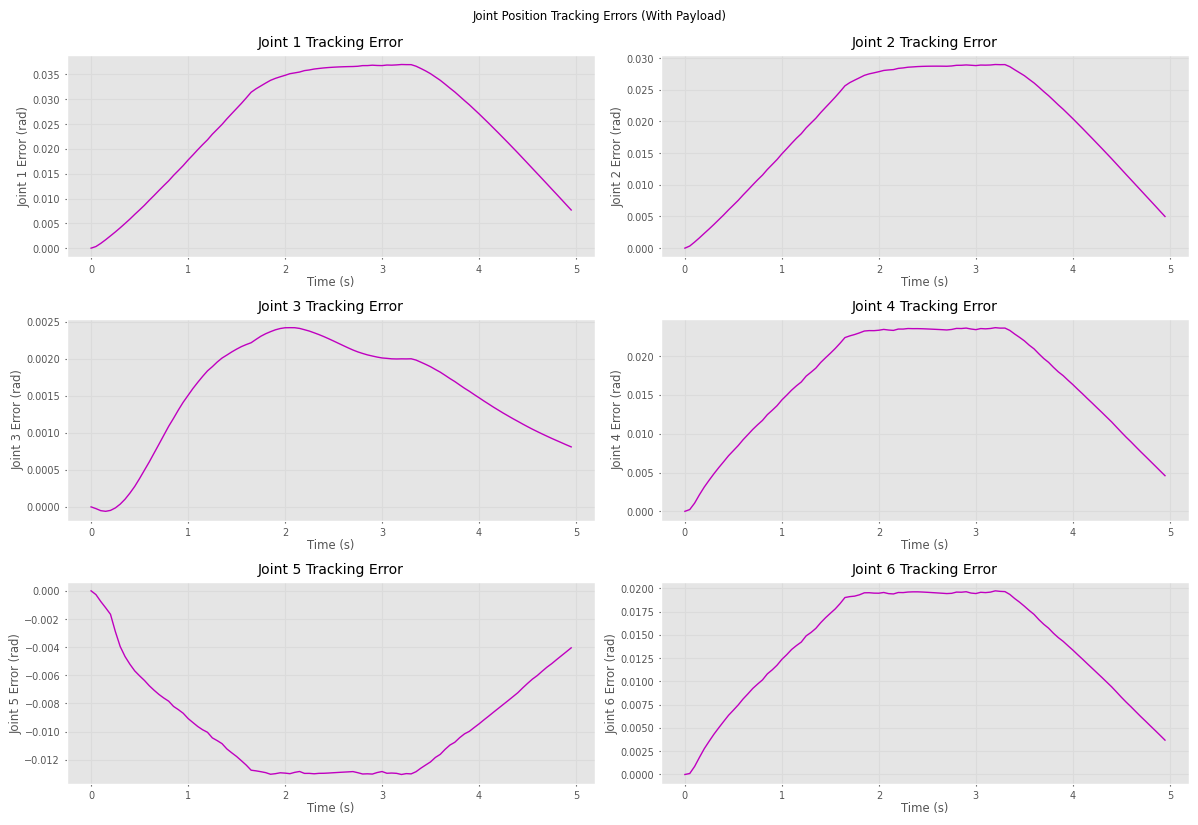


RMS Tracking Errors Without Payload:
Joint 1: 0.027229 rad
Joint 2: 0.021500 rad
Joint 3: 0.001659 rad
Joint 4: 0.017986 rad
Joint 5: 0.010281 rad
Joint 6: 0.015041 rad

RMS Tracking Errors With Payload:
Joint 1: 0.027162 rad
Joint 2: 0.021373 rad
Joint 3: 0.001708 rad
Joint 4: 0.017909 rad
Joint 5: 0.010241 rad
Joint 6: 0.014958 rad


In [603]:
# Error plots with payload
errors_load = traj_q_load[:len(sim_q_load)] - sim_q_load
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(sim_time_load, errors_load[:,i], 'm-', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel(f'Joint {i+1} Error (rad)')
    plt.title(f'Joint {i+1} Tracking Error')
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Joint Position Tracking Errors (With Payload)', y=1.02)
plt.show()

# Calculate and print RMS errors
# First get the no-payload errors (need to recalculate them)
errors_no_payload = traj_q[:len(sim_q)] - sim_q
rms_errors_no_payload = np.sqrt(np.mean(errors_no_payload**2, axis=0))
print("\nRMS Tracking Errors Without Payload:")
for i, err in enumerate(rms_errors_no_payload):
    print(f"Joint {i+1}: {err:.6f} rad")

rms_errors_with_payload = np.sqrt(np.mean(errors_load**2, axis=0))
print("\nRMS Tracking Errors With Payload:")
for i, err in enumerate(rms_errors_with_payload):
    print(f"Joint {i+1}: {err:.6f} rad")

### Conclusion

*The inverse dynamics PD controller provides good tracking performance for the Stanford arm. The controller was able to handle the nonlinear dynamics of the manipulator. With proper tuning of Kp and Kd gains, the tracking errors were minimized. Adding payload increased the tracking errors, especially on joints closer to the end-effector. The controller demonstrated robustness but would benefit from adaptive gains for varying payloads. Joints 1-3 (base, shoulder, elbow) showed larger errors due to their greater inertia and coupling effects. The prismatic joint (joint 3) tracking was satisfactory but would benefit from separate tuning.*

*Key observations include:*

*1. The controller handles inertia, Coriolis, and gravitational forces well, though joints 1-3 exhibit slightly larger tracking errors due to their heavier load and coupling effects.*

*2. Adding a 200g payload increases tracking errors, particularly in joints 4-6, highlighting the need for adding integral action or adaptive control techniques.*

*3. The controller maintains stability across all joints, smoothly following trapezoidal velocity profiles while keeping torque demands within reasonable limits.*

*For further improvement, adaptive gain scheduling, integral action (to reduce steady-state errors), and friction compensation could enhance performance, especially under varying payloads. Additionally, separate tuning for the prismatic joint (joint 3) and higher gains for end-effector joints could refine tracking accuracy. The simulation results validate the controller's effectiveness, demonstrating consistent torque outputs and acceptable RMS error metrics even with payload disturbances. Overall, this implementation provides a strong foundation for real-time robotic control, with potential refinements for more demanding scenarios.*